In [1]:
import os
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [2]:
cwd = os.getcwd()
os.chdir("..")

transform = v2.Compose([v2.Pad(2), v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_data = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)
test_data = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

os.chdir(cwd)
os.getcwd()

'c:\\Users\\USER\\ipnyb files\\Autoencoders'

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# model hyperparameters
LR = 0.001
PATIENCE = 2
IMAGE_SIZE = 32
CHANNELS = 1
BATCH_SIZE = 64
EMBEDDING_DIM = 2
EPOCHS = 10

# create output directory
output_dir = "output/conv_auto_enc"
os.makedirs(output_dir, exist_ok=True)


# model_weights directory inside the output directory
# for storing autoencoder weights
model_weights_dir = os.path.join(output_dir, "model_weights")
os.makedirs(model_weights_dir, exist_ok=True)

In [4]:
# define model_weights, reconstruction & real before training images path
MODEL_WEIGHTS_PATH = os.path.join(model_weights_dir, "best_autoencoder.pt")

# define class labels dictionary
CLASS_LABELS = {k: v for k, v in (enumerate(train_data.classes))}

In [5]:
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
def extract_random_images(data_loader, num_images):
    all_images = []
    all_labels = []

    for images, labels in data_loader:
        all_images.append(images)
        all_labels.append(labels)

    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)

    indices = torch.randperm(len(all_images))[:num_images]

    return all_images[indices], all_labels[indices]

In [7]:
def display_images(images, labels, title, num_images_per_row=5):

    num_images = len(images)
    num_rows = (num_images + num_images_per_row - 1) // num_images_per_row

    fig, axes = plt.subplots(num_rows, num_images_per_row, figsize=(10, 2 * num_rows))

    # Make axes iterable even if there is only one row
    axes = axes.flatten()

    for i in range(num_images):
        # squeeze() is used in PyTorch to remove dimensions whose size is 1.
        # This is particularly useful with FashionMNIST, because each grayscale image has one color channel
        image = images[i].detach().cpu().squeeze()

        axes[i].imshow(image, cmap="gray")
        axes[i].set_title(CLASS_LABELS[labels[i].item()])
        axes[i].axis("off")

    # Hide unused spaces
    for i in range(num_images, len(axes)):
        axes[i].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [8]:
def display_random_images(
    data_loader,
    encoder=None,
    decoder=None,
    title_recon=None,
    title_real=None,
    display_real=True,
    num_images=32,
    num_images_per_row=8,
):
    # extract a random subset of images and labels from the data loader
    random_images, random_labels = extract_random_images(data_loader, num_images)

    # if an encoder and decoder are provided,
    # use them to generate reconstructions
    if encoder is not None and decoder is not None:
        # set the encoder and decoder to evaluation mode
        encoder.eval()
        decoder.eval()
        random_images = random_images.to(DEVICE)

        random_embeddings = encoder(random_images)
        random_reconstructions = decoder(random_embeddings)

        display_images(
            random_reconstructions.cpu(),
            random_labels,
            title_recon,
            num_images_per_row,
        )

        if display_real:
            display_images(
                random_images.cpu(),
                random_labels,
                title_real,
                num_images_per_row,
            )

    # if no encoder and decoder are provided, simply display the original images
    else:
        display_images(random_images, random_labels, "Real Images", num_images_per_row)

In [9]:
def validate(encoder, decoder, test_loader, criterion):
    encoder.eval()
    decoder.eval()

    running_loss = 0.0

    with torch.no_grad():
        for batch_idx, (data, _) in tqdm(
            enumerate(test_loader), total=len(test_loader)
        ):
            data = data.to(DEVICE)
            encoded = encoder(data)
            decoded = decoder(encoded)
            loss = criterion(decoded, data)

            running_loss += loss.item()

    return running_loss / len(test_loader)

In [10]:
def get_test_embeddings(test_loader, encoder):
    encoder.eval()

    points = []
    label_idcs = []

    for i, data in enumerate(test_loader):
        img, label = [d.to(DEVICE) for d in data]

        proj = encoder(img)

        points.extend(proj.detach().cpu().numpy())
        label_idcs.extend(label.detach().cpu().numpy())

        del img, label

    points = np.array(points)
    label_idcs = np.array(label_idcs)

    return points, label_idcs

In [11]:
def plot_latent_space(test_loader, encoder):
    points, label_idcs = get_test_embeddings(test_loader, encoder)

    fig, ax = plt.subplots(figsize=(10, 10))

    scatter = ax.scatter(
        x=points[:, 0],
        y=points[:, 1],
        s=2.0,
        c=label_idcs,
        cmap="tab10",
        alpha=0.9,
        zorder=2,
    )
    # remove the top and right spines from the plot
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.ax.set_ylabel("Labels", rotation=270, labelpad=20)

    ax.grid(True, color="lightgray", alpha=1.0, zorder=0)
    plt.show()

In [12]:
def get_random_test_images_embeddings(test_loader, encoder, imgs_visualize=5000):
    all_images, all_labels = [], []
    for batch in test_loader:
        images_batch, labels_batch = batch
        all_images.append(images_batch)
        all_labels.append(labels_batch)

    # concatenate all the images and labels into a single tensor
    all_images = torch.cat(all_images, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    index = np.random.choice(range(len(all_images)), imgs_visualize)
    images = all_images[index]
    labels = all_labels[index]

    points, _ = get_test_embeddings(test_loader, encoder)
    embeddings = points[index]

    return images, labels, embeddings

In [13]:
def plot_image_grid_on_embeddings(
    test_loader, encoder, decoder, grid_size=15, figsize=12
):
    # get a random subset of test images
    # and their corresponding embeddings and labels
    _, labels, embeddings = get_random_test_images_embeddings(test_loader, encoder)
    # create a single figure for the plot
    fig, ax = plt.subplots(figsize=(figsize, figsize))
    # define a custom color map with discrete colors for each unique label
    unique_labels = np.unique(labels)
    num_classes = len(unique_labels)
    cmap = plt.colormaps.get_cmap("rainbow").resampled(num_classes)
    bounds = np.linspace(0, num_classes, num_classes + 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    # Plot the scatter plot of the embeddings colored by label
    scatter = ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        cmap=cmap,
        c=labels,
        norm=norm,
        alpha=0.8,
        s=300,
    )
    # Create the colorbar with discrete ticks corresponding to unique labels
    cb = plt.colorbar(scatter, ticks=range(num_classes), spacing="proportional", ax=ax)
    cb.set_ticklabels(unique_labels)

    # Create the grid of images to overlay on the scatter plot
    x = np.linspace(embeddings[:, 0].min(), embeddings[:, 0].max(), grid_size)
    y = np.linspace(embeddings[:, 1].max(), embeddings[:, 1].min(), grid_size)
    xv, yv = np.meshgrid(x, y)
    grid = np.column_stack((xv.ravel(), yv.ravel()))
    # convert the numpy array to a PyTorch tensor
    # and get reconstructions from the decoder
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    reconstructions = decoder(grid_tensor.to(DEVICE))
    # overlay the images on the scatter plot
    for i, (grid_point, img) in enumerate(zip(grid, reconstructions)):
        img = img.squeeze().detach().cpu().numpy()
        imagebox = OffsetImage(img, cmap="Greys", zoom=0.5)
        ab = AnnotationBbox(
            imagebox, grid_point, frameon=False, pad=0.0, box_alignment=(0.5, 0.5)
        )
        ax.add_artist(ab)

    plt.show()

## Encoder


In [14]:
from typing import Any


class Encoder(nn.Module):
    def __init__(
        self, image_size, channels, embedding_dim, *args: Any, **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)

        self.conv_seq = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.shape_before_flattening = None
        # Calculate flattened size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, channels, image_size, image_size)
            x = self.conv_seq(dummy)

            flattened_size = x.flatten(1).shape[1]

        self.fc = nn.Linear(flattened_size, embedding_dim)

    def forward(self, x):
        x = self.conv_seq(x)

        self.shape_before_flattening = x.shape[1:]

        x = x.flatten(1)
        x = self.fc(x)

        return x

In [15]:
from typing import Any


class Decoder(nn.Module):
    def __init__(
        self,
        embedding_dim,
        shape_before_flattening,
        channels,
        *args: Any,
        **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)

        self.fc = nn.Linear(embedding_dim, np.prod(shape_before_flattening))
        self.reshape_dim = shape_before_flattening

        self.conv_transpose_seq = nn.Sequential(
            nn.ConvTranspose2d(
                128, 128, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                128, 64, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(32, channels, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.reshape(x.shape[0], *self.reshape_dim)

        return self.conv_transpose_seq(x)

In [16]:
encoder = Encoder(
    channels=CHANNELS,
    image_size=IMAGE_SIZE,
    embedding_dim=EMBEDDING_DIM,
).to(DEVICE)

dummy_input = torch.zeros(1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
enc_out = encoder(dummy_input.to(DEVICE))
shape_before_flattening = encoder.shape_before_flattening

decoder = Decoder(EMBEDDING_DIM, shape_before_flattening, CHANNELS).to(DEVICE)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.1, patience=PATIENCE
)

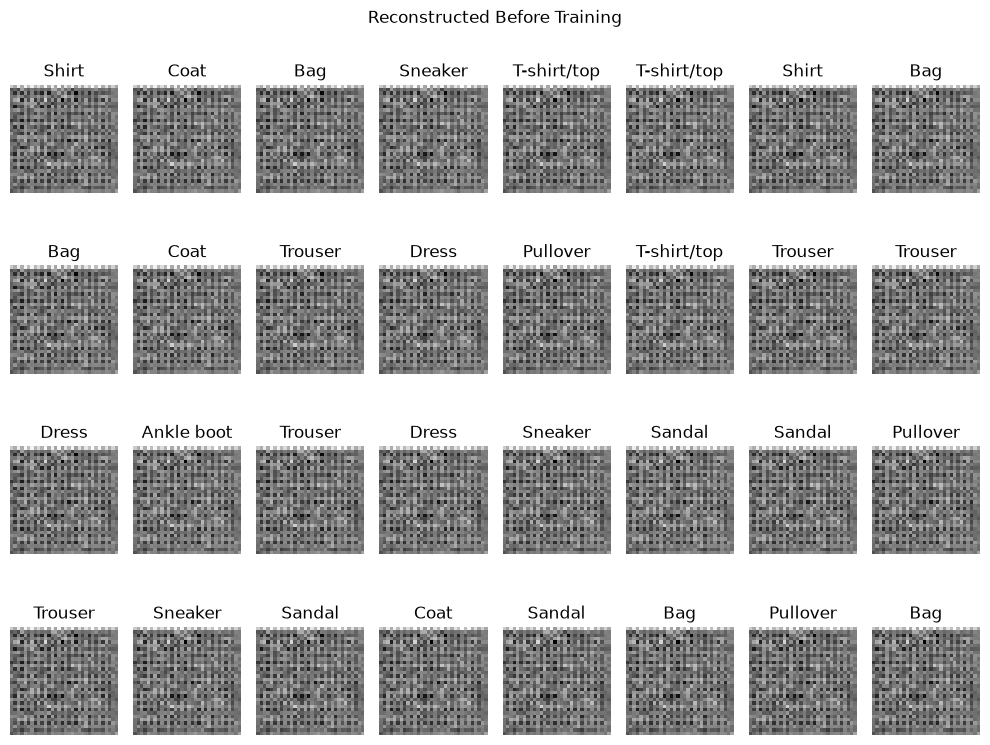

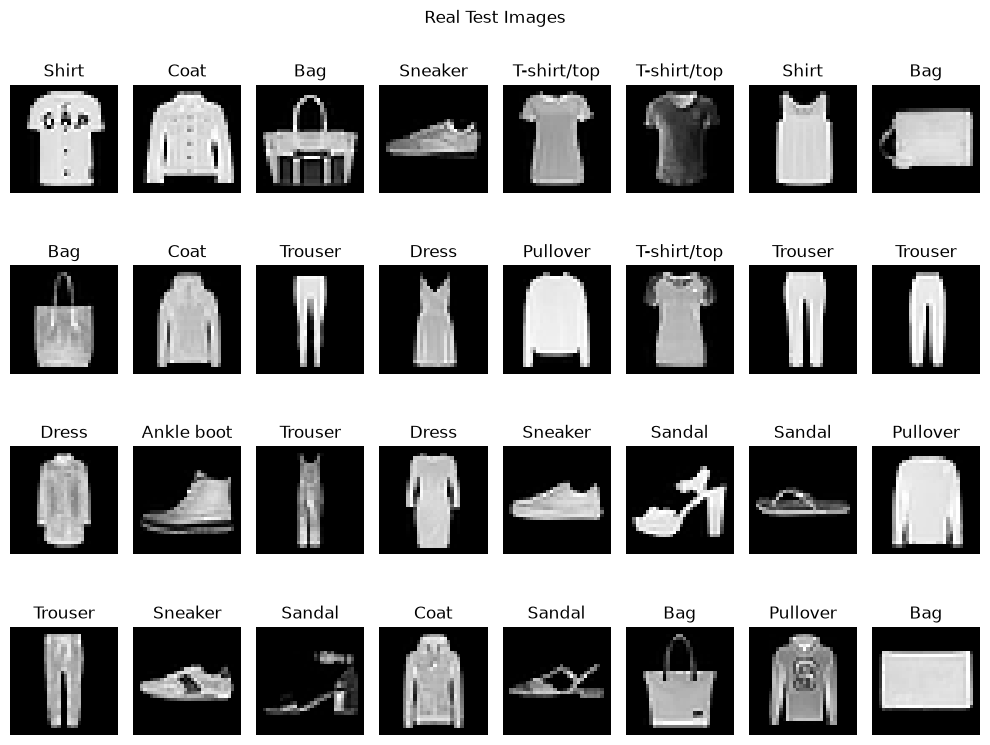

In [17]:
display_random_images(
    test_dataloader,
    encoder,
    decoder,
    title_recon="Reconstructed Before Training",
    title_real="Real Test Images",
)

Epoch: 1/10


100%|██████████| 157/157 [00:01<00:00, 91.27it/s]


Epoch 1 | Train Loss: 0.2791 | Val Loss: 0.2582


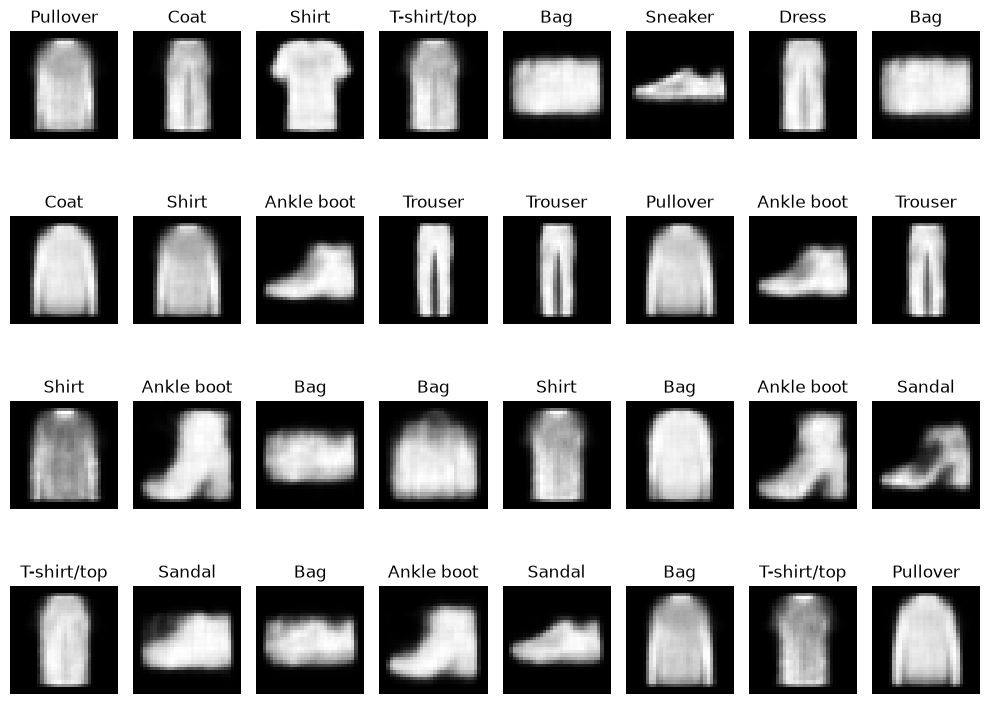

Epoch: 2/10


100%|██████████| 157/157 [00:01<00:00, 98.20it/s] 


Epoch 2 | Train Loss: 0.2548 | Val Loss: 0.2534


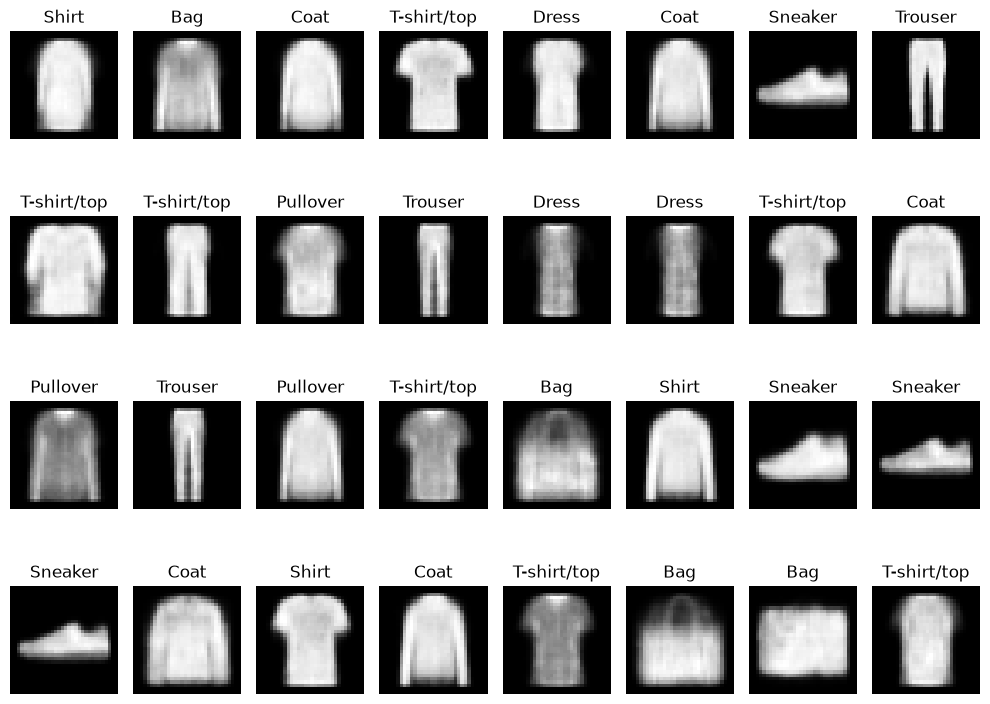

Epoch: 3/10


100%|██████████| 157/157 [00:01<00:00, 92.89it/s]


Epoch 3 | Train Loss: 0.2514 | Val Loss: 0.2522


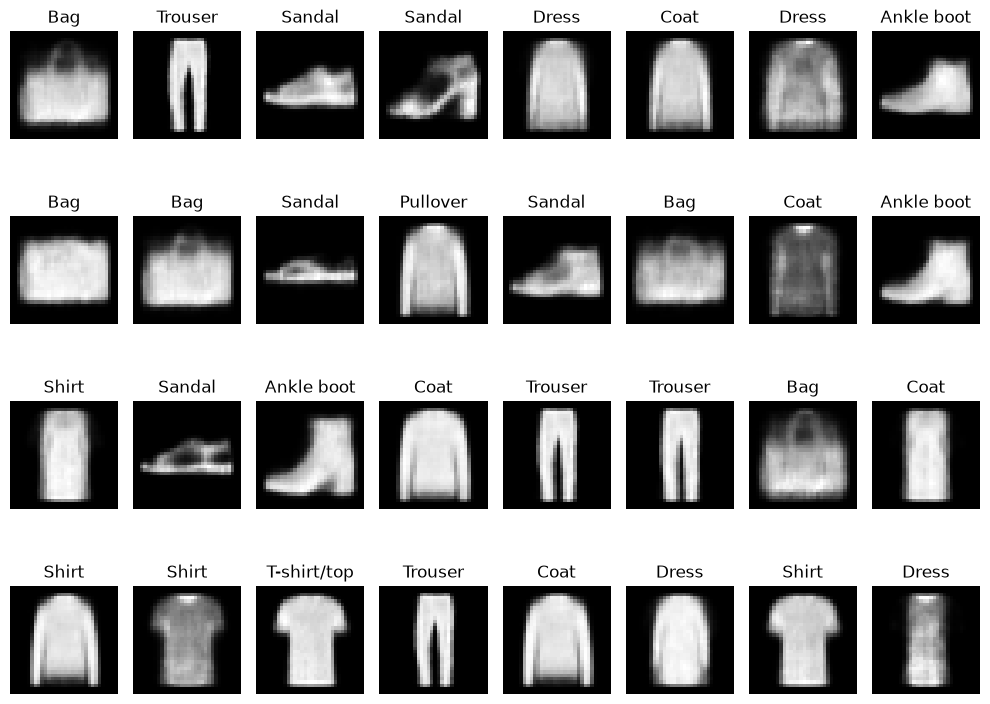

Epoch: 4/10


100%|██████████| 157/157 [00:01<00:00, 93.95it/s]


Epoch 4 | Train Loss: 0.2496 | Val Loss: 0.2505


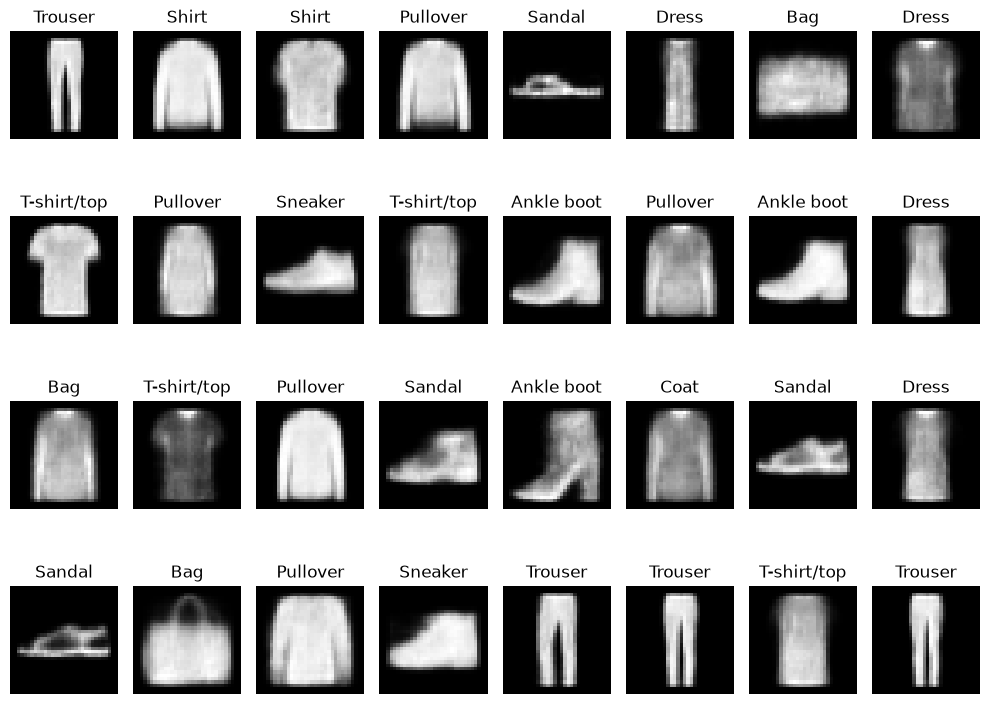

Epoch: 5/10


100%|██████████| 157/157 [00:01<00:00, 103.47it/s]


Epoch 5 | Train Loss: 0.2483 | Val Loss: 0.2495


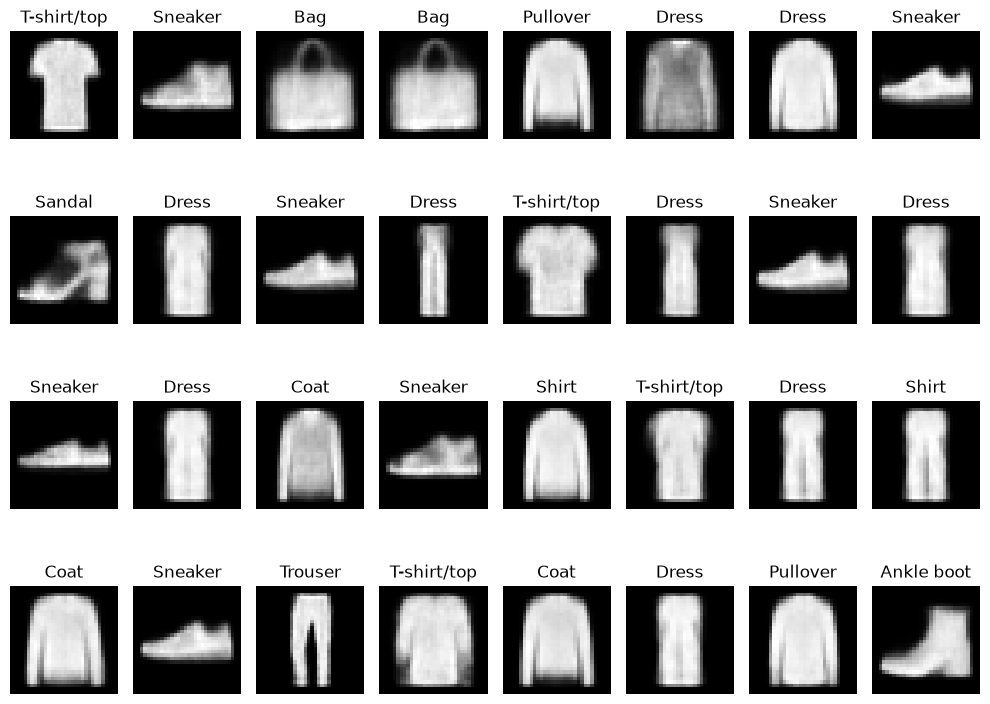

Epoch: 6/10


100%|██████████| 157/157 [00:01<00:00, 95.28it/s]


Epoch 6 | Train Loss: 0.2475 | Val Loss: 0.2488


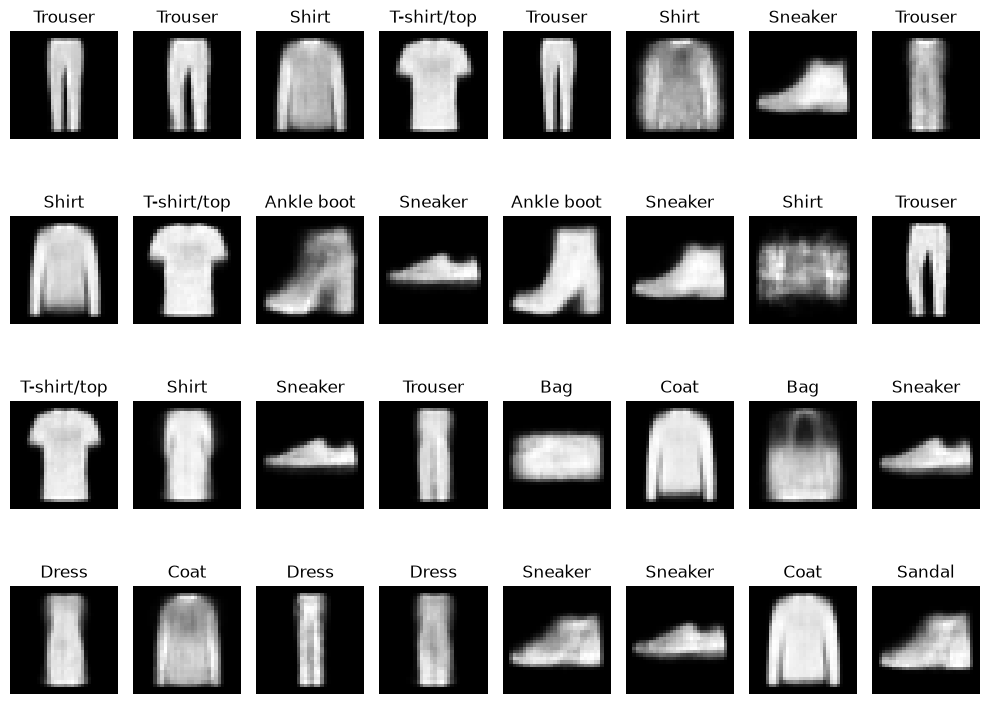

Epoch: 7/10


100%|██████████| 157/157 [00:01<00:00, 97.31it/s] 


Epoch 7 | Train Loss: 0.2467 | Val Loss: 0.2490


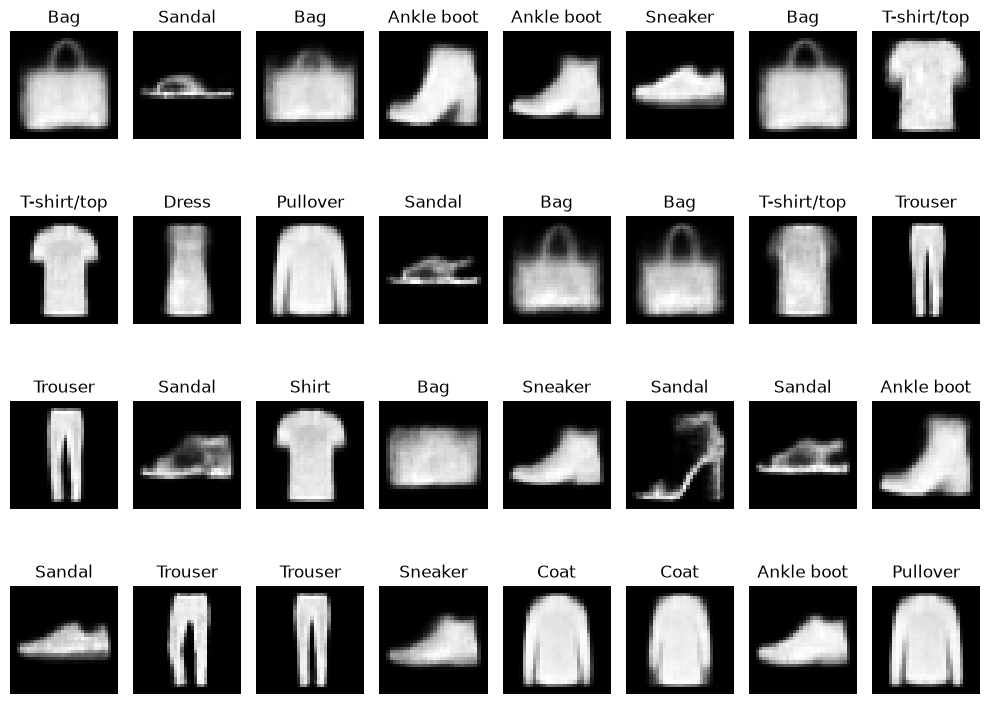

Epoch: 8/10


100%|██████████| 157/157 [00:02<00:00, 72.58it/s]


Epoch 8 | Train Loss: 0.2460 | Val Loss: 0.2481


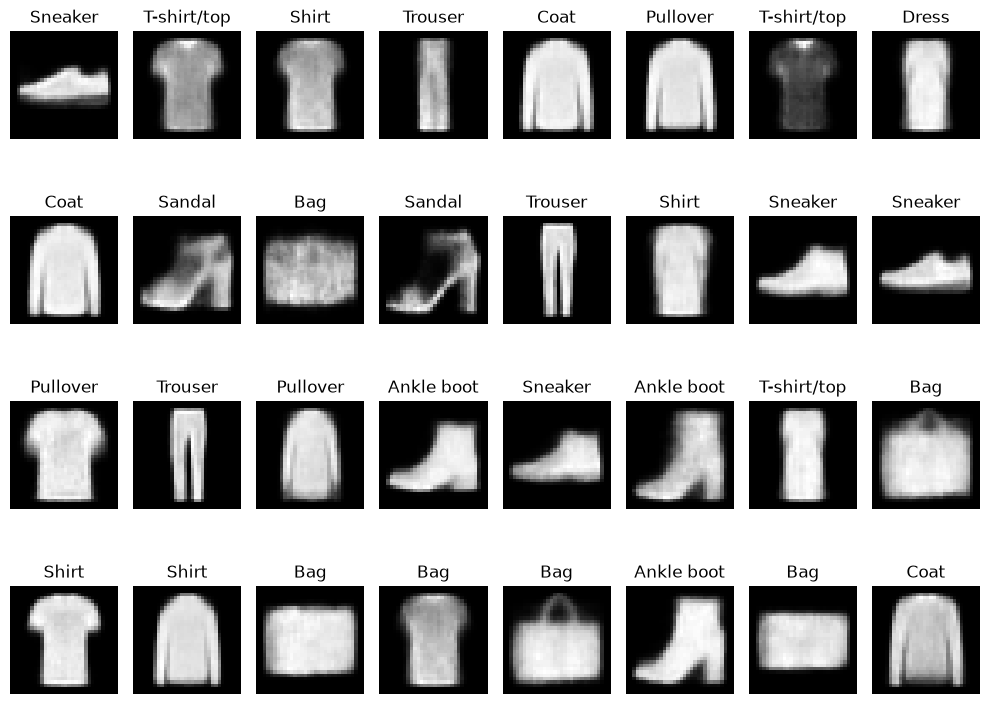

Epoch: 9/10


100%|██████████| 157/157 [00:01<00:00, 85.31it/s]


Epoch 9 | Train Loss: 0.2456 | Val Loss: 0.2474


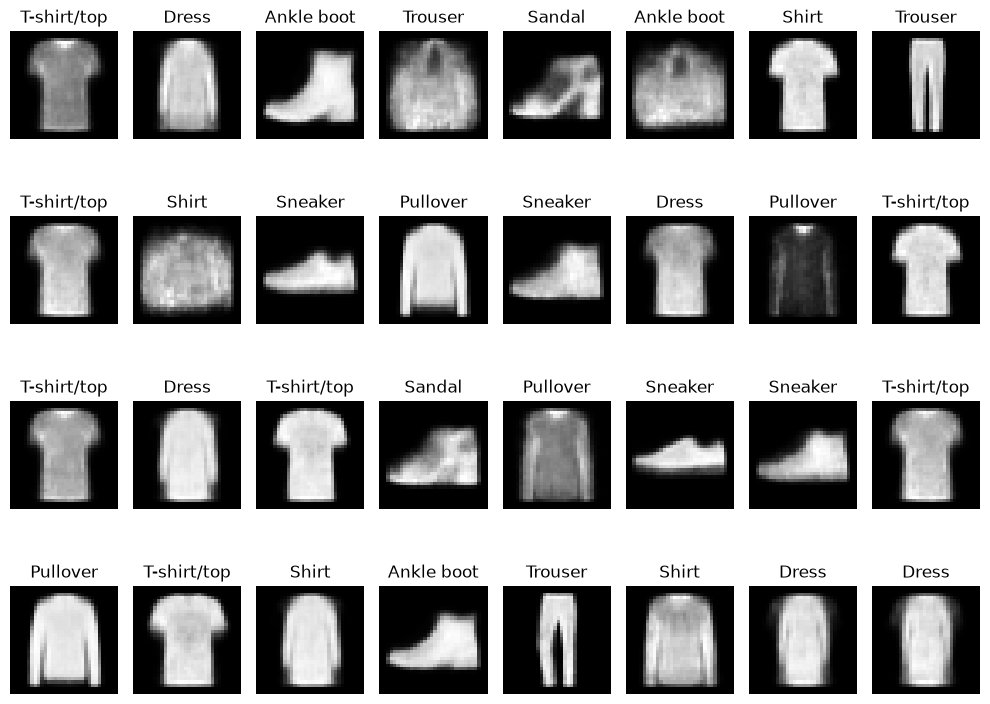

Epoch: 10/10


100%|██████████| 157/157 [00:01<00:00, 86.84it/s]


Epoch 10 | Train Loss: 0.2451 | Val Loss: 0.2467


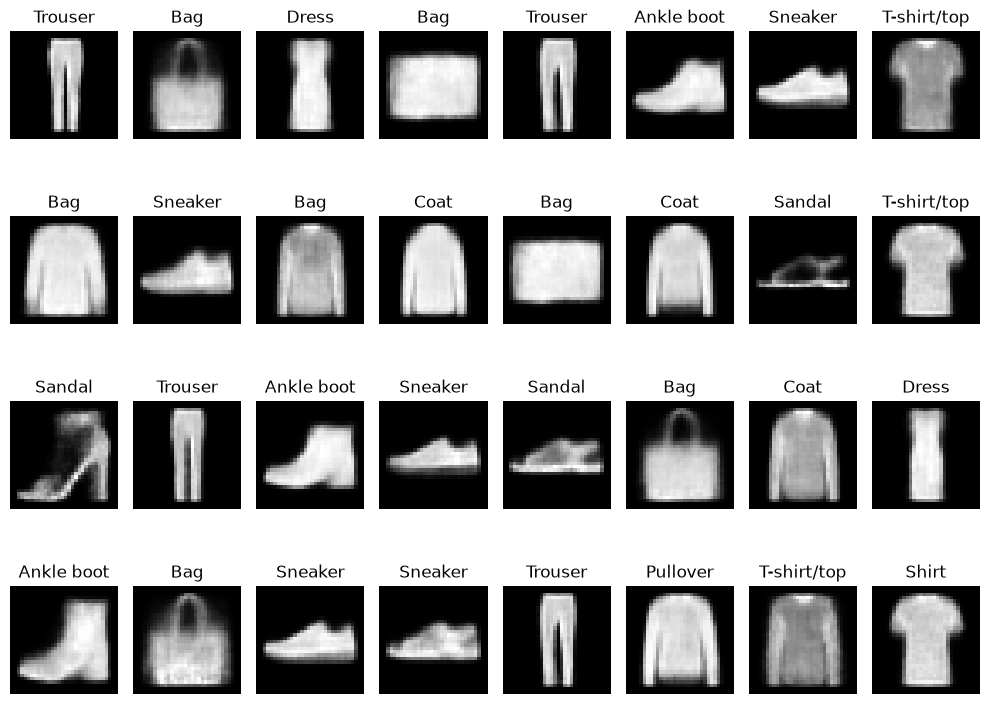

Training finished!


In [18]:
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    print(f"Epoch: {epoch + 1}/{EPOCHS}")

    encoder.train()
    decoder.train()

    running_loss = 0.0

    for batch_idx, (data, _) in tqdm(
        enumerate(train_dataloader), total=len(train_dataloader)
    ):
        optimizer.zero_grad()

        data = data.to(DEVICE)

        encoded = encoder(data)
        decoded = decoder(encoded)

        loss = criterion(decoded, data)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_dataloader)
    val_loss = validate(encoder, decoder, test_dataloader, criterion)
    print(
        f"Epoch {epoch + 1} | Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {"encoder": encoder.state_dict(), "decoder": decoder.state_dict()},
            MODEL_WEIGHTS_PATH,
        )

    scheduler.step(val_loss)

    display_random_images(
        data_loader=test_dataloader,
        encoder=encoder,
        decoder=decoder,
        display_real=False,
    )
print("Training finished!")

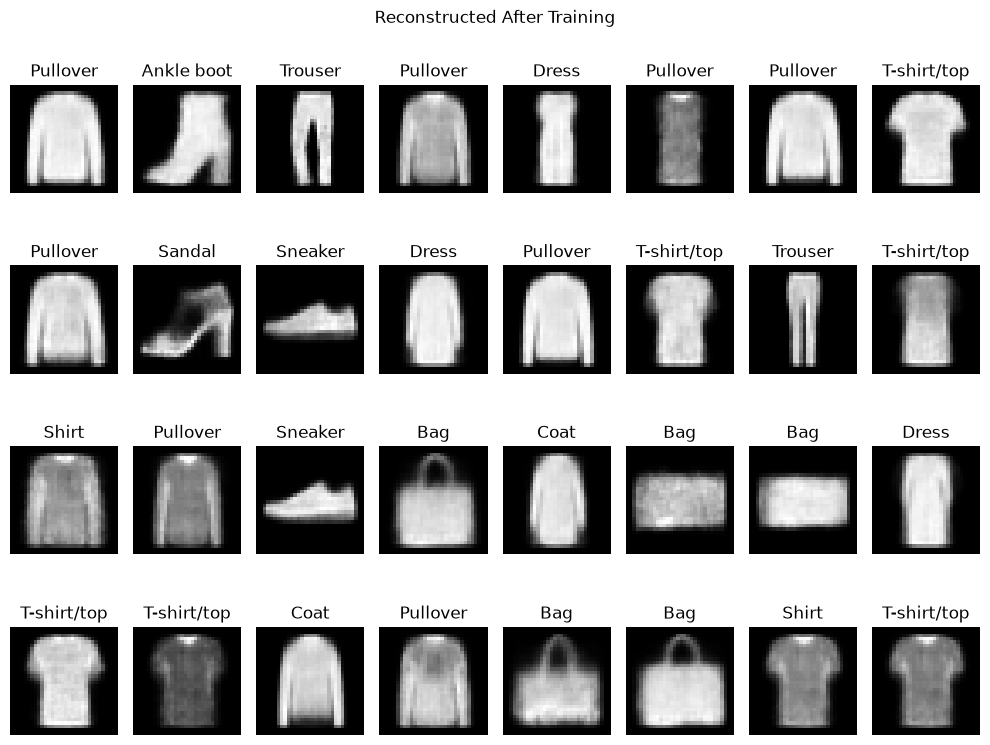

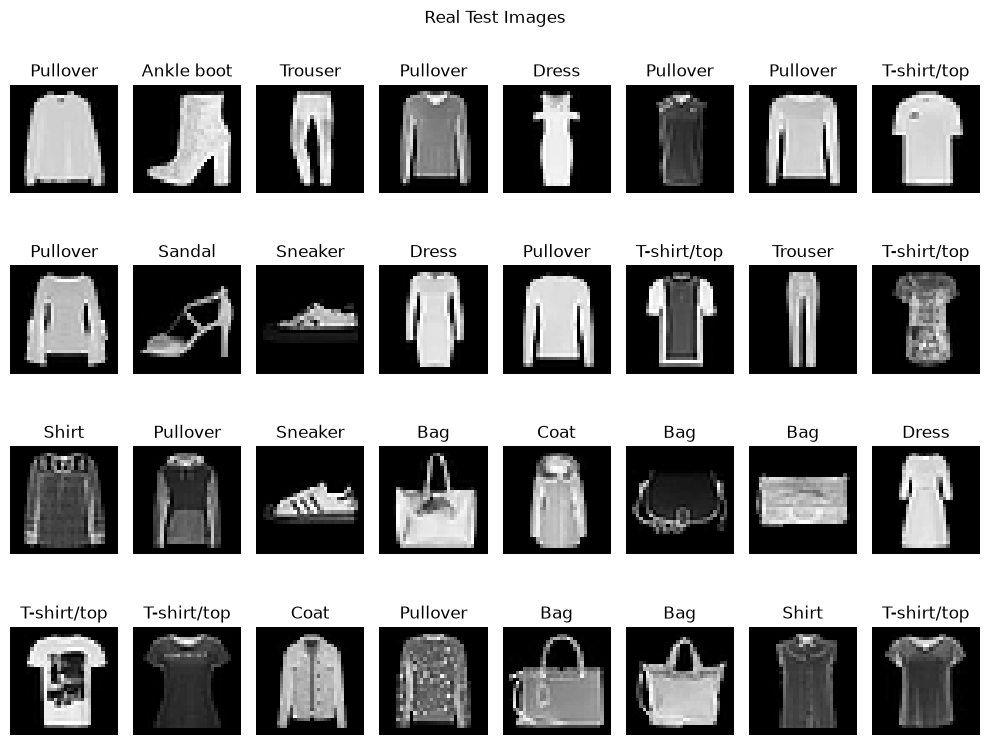

In [19]:
display_random_images(
    test_dataloader,
    encoder,
    decoder,
    title_recon="Reconstructed After Training",
    title_real="Real Test Images",
)

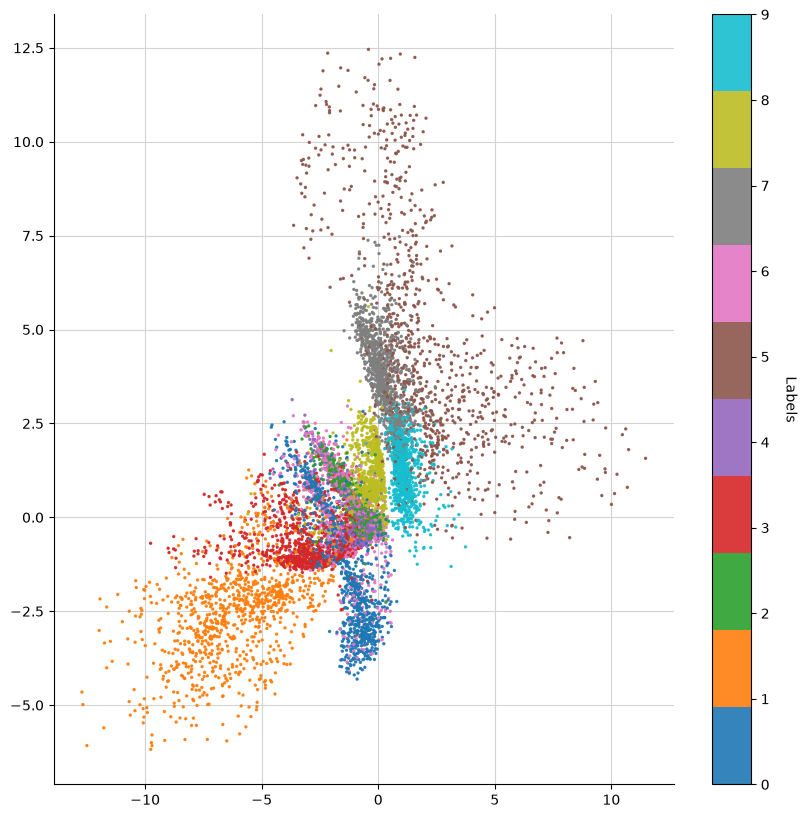

In [20]:
plot_latent_space(test_dataloader, encoder)

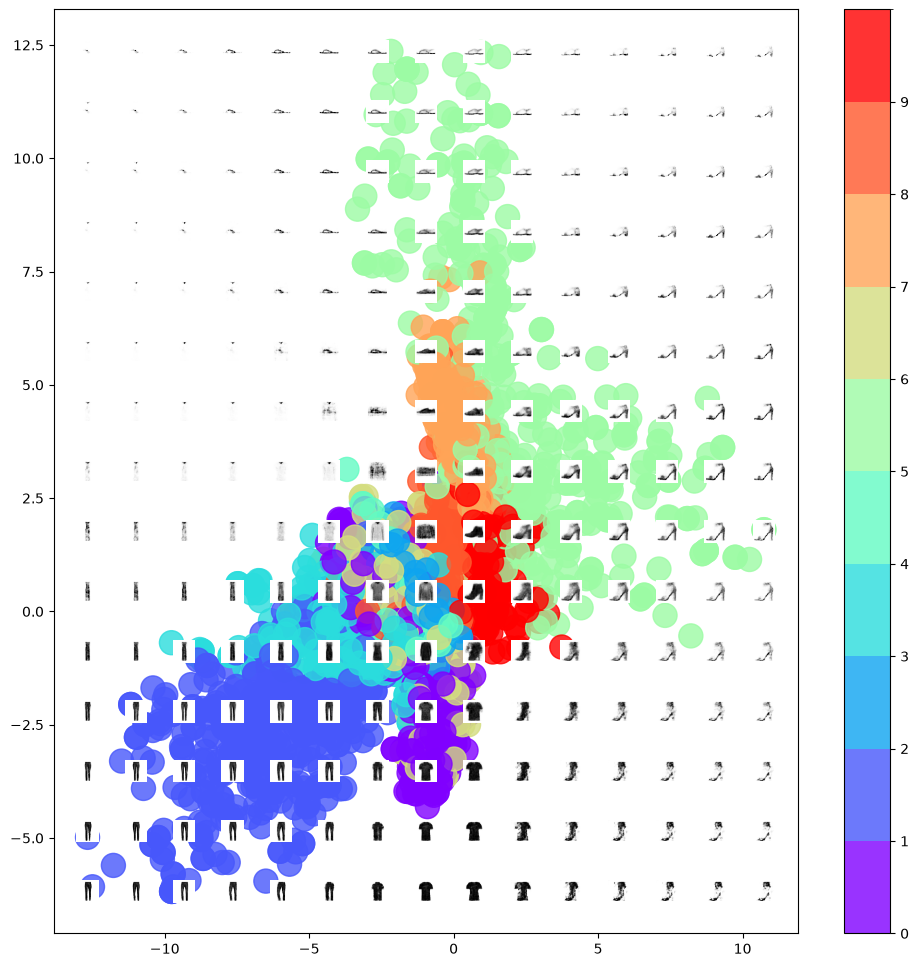

In [21]:
plot_image_grid_on_embeddings(test_dataloader, encoder, decoder)

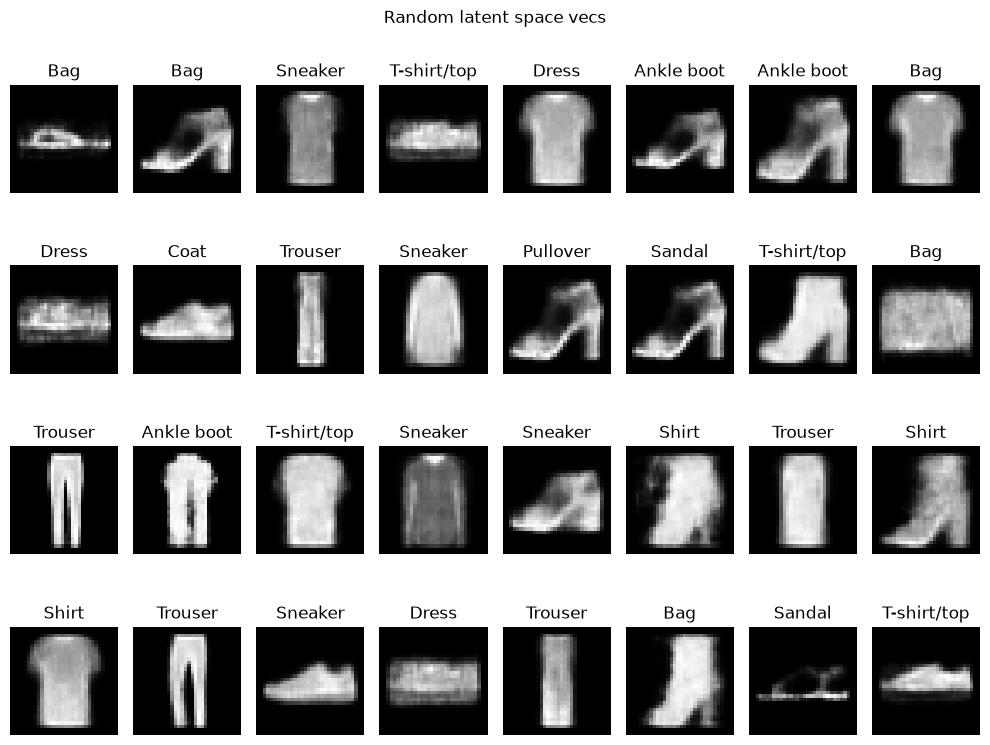

In [22]:
encoder.eval()
decoder.eval()

with torch.no_grad():

    for x, y in train_dataloader:

        x = x.to(DEVICE)
        embeddings = encoder(x)

        random_noise = torch.randn_like(embeddings)
        random_embeddings = embeddings + (3 * random_noise)

        generated_images = decoder(random_embeddings)

display_images(generated_images.cpu(), y.cpu(), "Random latent space vecs", 8)

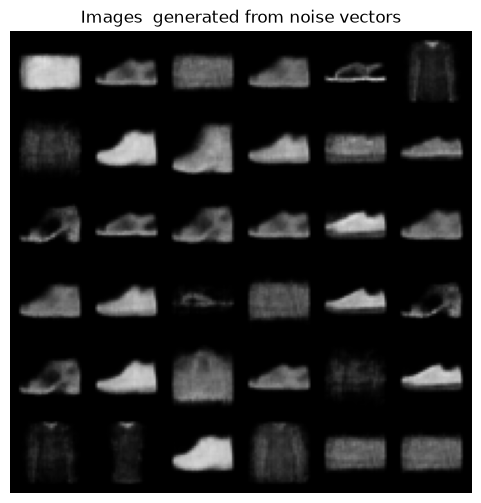

In [30]:
from torchvision.utils import make_grid

with torch.no_grad():
    noise_vecs = torch.randn(36, 1, 32, 32)
    embeddings = encoder.cpu()(noise_vecs)
    recon = decoder.cpu()(embeddings)
    gen_imgs = make_grid(recon, nrow=6).permute(1, 2, 0)

plt.figure(figsize=(6, 6))
plt.imshow(gen_imgs, cmap="gray")
plt.title("Images  generated from noise vectors")
plt.axis(False)
plt.show()